Import all necessary libraries and read in the data:

1. Read in carseats data and get an overview of the data.

In [1]:
import pandas as pd

cars = pd.read_csv("cars_multivariate.csv")

cars.head(n=2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320


2.a) Create scatterplot showing the relationship between mpg and other features.

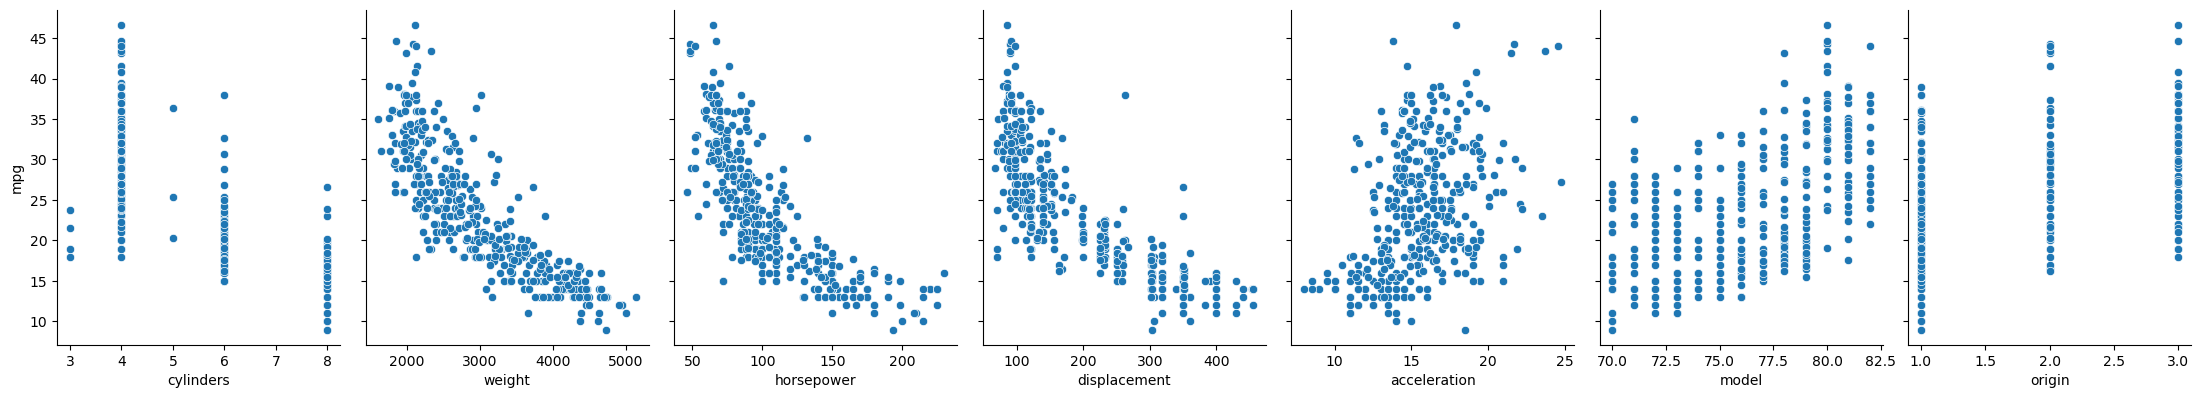

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
# Pairplot
sns.pairplot(cars, x_vars=['cylinders','weight','horsepower','displacement','acceleration','model', 'origin'], y_vars='mpg', height=4, aspect=0.8)
plt.show()

2.b) From visual inspection, what is the relationship between the variables?

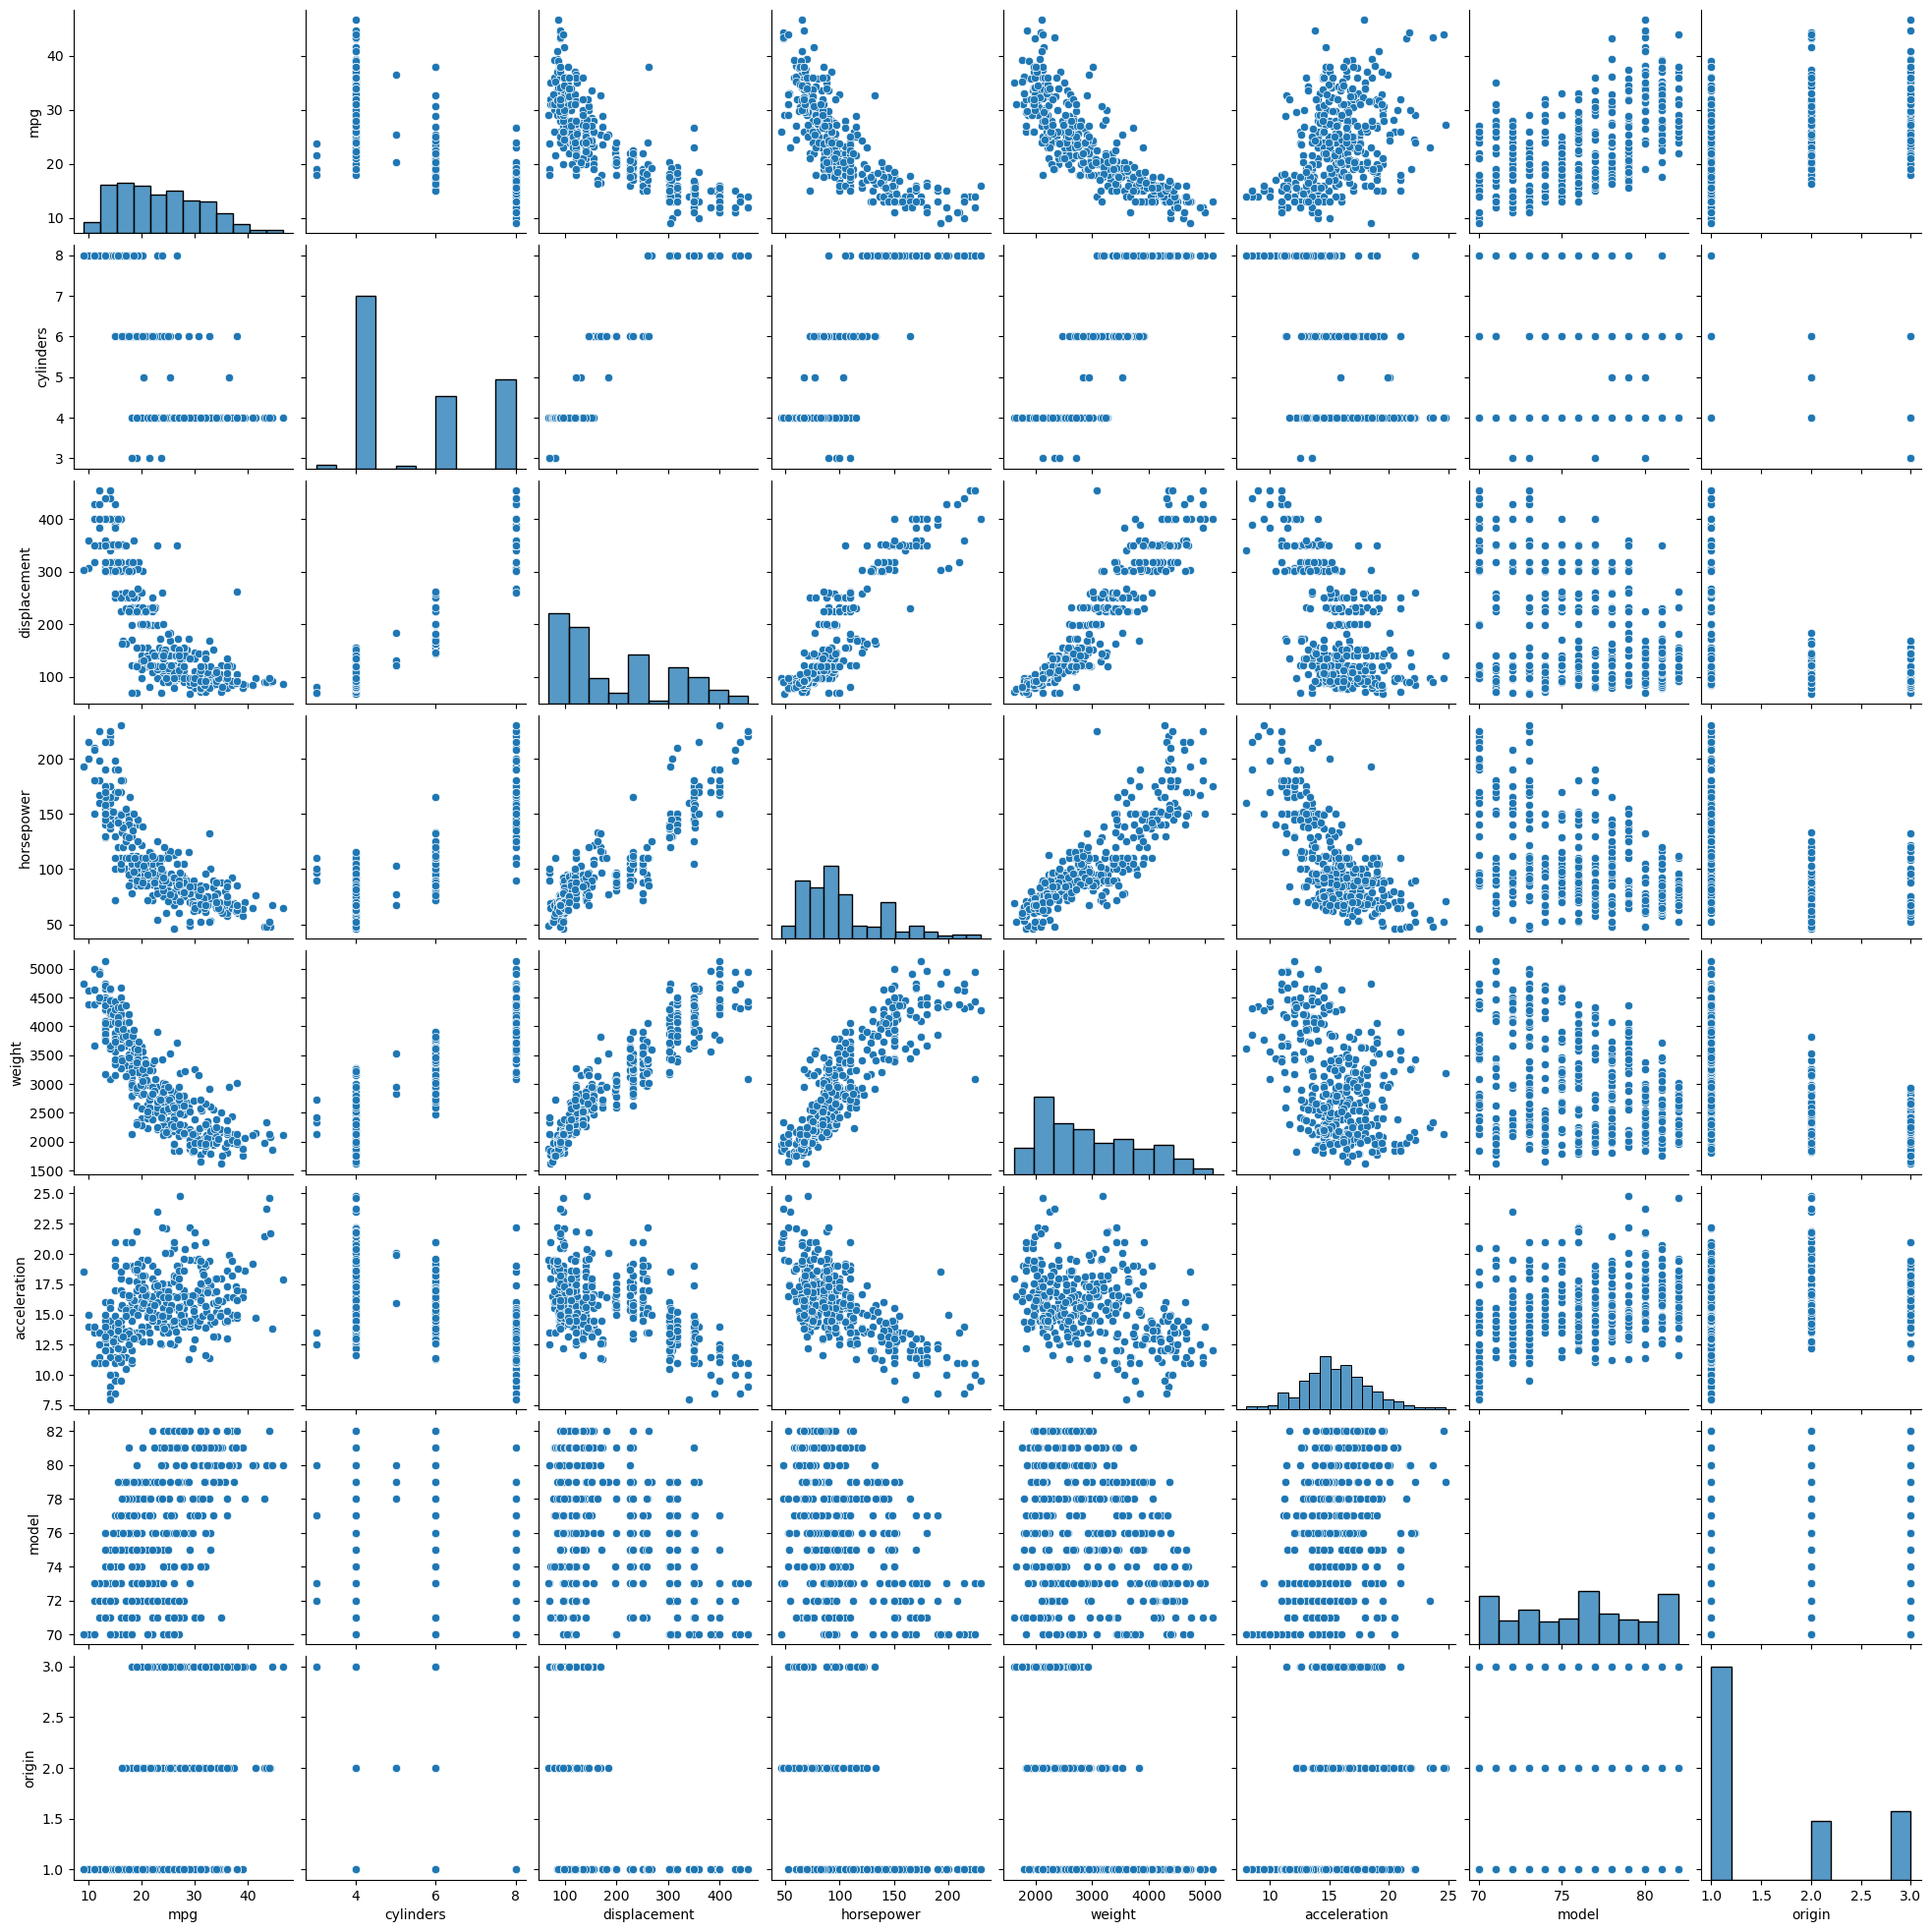

In [3]:
import seaborn as sns

sns.pairplot(cars)
plt.show()

**Conclusion:**

1: From the scatterplot we can see that mpg has linear relationship with displacement, horsepower, weight, acceleration, but no linear relationship with cylinder, model, origin.

2: From the scatterplot we can also see that displacement horsepower, weight and acceleration are also linearly correlated with each other.

2.c) Correlation matrix

In [4]:
# Calculate the correlation matrix for the cars dataset
import seaborn as sns
import matplotlib.pyplot as plt

corr = cars.corr(numeric_only=True)
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
model,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


2.d) Visulization of correlation matrix

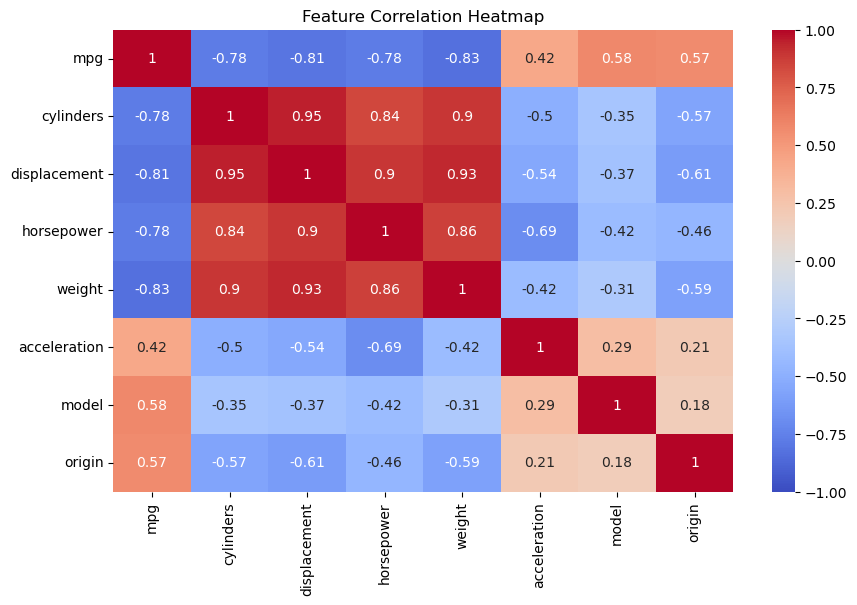

In [5]:
# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

2.e) VIF → quantify multicollinearity

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X= cars[['cylinders','weight','horsepower','displacement','acceleration','model', 'origin']]
y= cars['mpg']
X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif)

       Variable         VIF
0         const  763.557531
1     cylinders   10.737535
2        weight   10.831260
3    horsepower    9.943693
4  displacement   21.836792
5  acceleration    2.625806
6         model    1.244952
7        origin    1.772386


**Conclusion:**

**Positive linear relationships**:

Acceleration — positive trend, but very wide scatter, weak fit

Model — positive trend, reasonably linear

**Strong negative linear relationships**:

Weight — quite linear, tight fit

Horsepower — reasonably linear, though slightly curved

Displacement — similar to horsepower, somewhat curved

**Weak/questionable linear relationships**:

Cylinders — discrete variable (3, 4, 6, 8), so regression is technically valid but the relationship is stepped, not truly continuous-linear

Origin — also discrete/categorical (1, 2, 3)


**Solution:**

Encode categoricals (one-hot: cylinders, origin)

Transform skewed features (log/sqrt: horsepower, displacement, weight)

Scale all features (StandardScaler)

Apply Lasso

3. Feature engineering (fix non-linearity)

In [7]:
import numpy as np

# log() transforms: Fixes shape of relationship (curve → straight line) and reduces impact of outliers.
cars['log_horsepower']  = np.log(cars['horsepower'])
cars['log_weight']      = np.log(cars['weight'])
cars['log_displacement']= np.log(cars['displacement'])

4. Define features 

In [8]:
# Categorical features like cylinders and origin need one-hot encoding. 
categorical_features = ['cylinders', 'origin'] # According to the dataset description for origin: 1=American, 2=European, 3=Japanese      
numerical_features   = ['log_weight', 'log_horsepower',
                         'log_displacement', 'acceleration', 'model']

X = cars[categorical_features + numerical_features]
y = cars['mpg']

5. Preprocessor

In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# OneHotEncoder(drop='first'): Converts cylinders & origin to binary columns, drops one to avoid multicollinearity.
# StandardScaler(): Fixes scale differences between features (e.g. weight vs acceleration) so Lasso can compare coefficients on the same scale.
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
    ('num', StandardScaler(), numerical_features)
])


6.a) Split data into training/test set

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Lasso Regression Model

6.b) Find best alpha with cross-validation

Lasso is Linear Regression with a penalty that forces unimportant feature coefficients to exactly zero — effectively removing them from the model. Besides, it predicts the result directly.

**Lasso = Linear Regression + Automatic Feature Selection**

Alpha is the regularization strength — it controls how aggressively Lasso shrinks coefficients toward zero.

**α = 0 means no regularization → regular linear regression**

**Small α means mild shrinkage, keeps most features**

**Large α means strong shrinkage, forces many coefficients to exactly 0 (feature selection)**

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, LassoCV

# Lasso CV: Tries many alpha values via cross-validation, picks the best one automatically
lasso_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LassoCV(cv=5, random_state=42))   # auto-finds best alpha
])

lasso_cv_pipeline.fit(X_train, y_train)
best_alpha = lasso_cv_pipeline.named_steps['model'].alpha_
print(f"Best alpha: {best_alpha:.4f}")

Best alpha: 0.0385


6.c) Check what alpha values Lasso CV tested

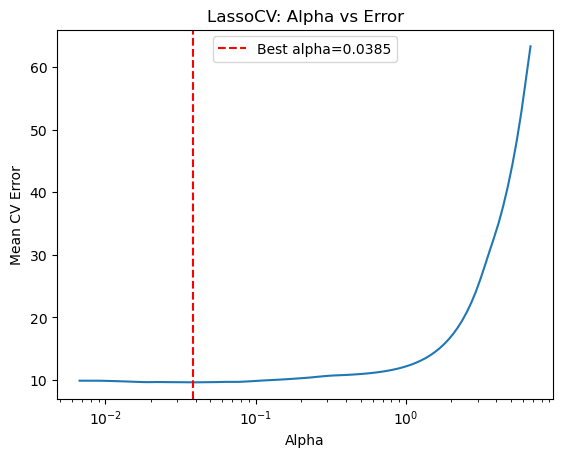

In [12]:
alphas = lasso_cv_pipeline.named_steps['model'].alphas_
mse_scores = lasso_cv_pipeline.named_steps['model'].mse_path_.mean(axis=1)

plt.plot(alphas, mse_scores)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha={best_alpha:.4f}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean CV Error')
plt.title('LassoCV: Alpha vs Error')
plt.legend()
plt.show()

**Conclusion:**

in this project the best alpha was 0.0385, which means:

Lasso CV preferred mild regularization

The data doesn't need aggressive feature elimination

The model is close to standard linear regression but with slight shrinkage

7.Residual plot

A residual plot is essentially a diagnostic tool — it checks whether your model's assumptions are valid and where it's failing.

If errors are random → your model has captured all the patterns.

If errors show a pattern → your model is leaving something on the table.

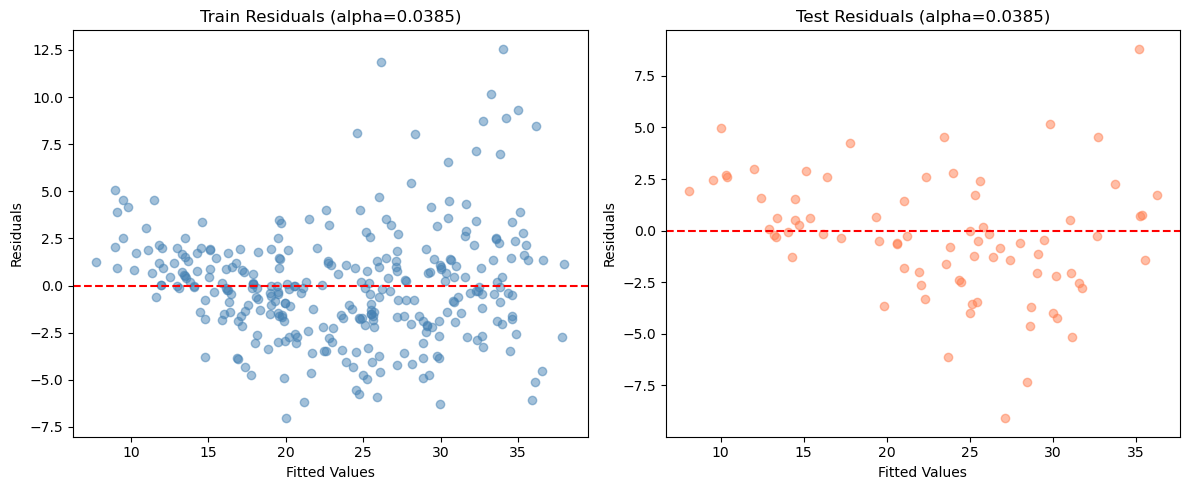

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_pred_train = lasso_cv_pipeline.predict(X_train)
y_pred_test = lasso_cv_pipeline.predict(X_test)

# Calculate residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training residuals
axes[0].scatter(y_pred_train, residuals_train, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Train Residuals (alpha={best_alpha:.4f})')

# Test residuals
axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'Test Residuals (alpha={best_alpha:.4f})')

plt.tight_layout()
plt.show()

**Conclusion: Lasso CV model with alpha=0.0385 is performing well.**

Scatter is roughly centered around 0 on both train and test — no systematic bias

Test residuals are actually tighter (±9 range) than train (±13 range) — no overfitting concern

No strong funnel shape — variance looks fairly consistent across fitted values

7. Evaluation of Lasso CV model on training/test set.

R² measures how much variance in y your model explains.

R² = 1 → perfect predictions

R² = 0 → model is no better than just predicting the mean

R² < 0 → model is worse than predicting the mean

7.a) Evaluate on training set

In [14]:
from sklearn.metrics import r2_score

# Cross-validation on original features with LASSO
lasso_train_r2 = r2_score(y_train, lasso_cv_pipeline.predict(X_train))
print("Lasso Train R²:", lasso_train_r2)

Lasso Train R²: 0.8611266916831762


7.b) Evaluate on test set

In [15]:
from sklearn.metrics import r2_score

lasso_test_r2  = r2_score(y_test,  lasso_cv_pipeline.predict(X_test))
print(f"Lasso Test R²:   {lasso_test_r2:.4f}")

Lasso Test R²:   0.8309


7.c) Comparison

In [16]:
print(f"Lasso Train R²:{lasso_train_r2:.4f}")
print(f"Lasso Test R²:{lasso_test_r2:.4f}")
print(f"Lasso Gap: {lasso_train_r2 - lasso_test_r2:.4f}")

Lasso Train R²:0.8611
Lasso Test R²:0.8309
Lasso Gap: 0.0302


**Conclusion:**

**Good Predictive Power**

Your model explains 84% of the variance in house prices on training data

It explains 83% of the variance on unseen test data

The remaining ~16% is noise or factors not in your dataset

**No Overfitting**

The gap is only 0.01 — essentially negligible

Train R² = 0.84

Test  R² = 0.83

Gap      = 0.01  ← excellent, anything < 0.05 is great

This means Lasso's regularization (alpha=0.0385) worked perfectly — it prevented the model from memorizing the training data.

**Generalizes Well**

The model performs almost identically on new, unseen data — this is the most important thing in machine learning.

8. See which features were kept/dropped by Lasso

In [17]:
feature_names = (
    lasso_cv_pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)
coefficients = lasso_cv_pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature':     feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False)

# Summary
kept   = coef_df[coef_df['coefficient'] != 0]
zeroed = coef_df[coef_df['coefficient'] == 0]

print(f"Features kept:    {len(kept)}")
print(f"Features removed: {len(zeroed)}")

print("\nFeature coefficients (0 = dropped by Lasso):")
print(coef_df.to_string(index=False))

print("\nRemoved features:")
print(zeroed['feature'].tolist())


Features kept:    9
Features removed: 2

Feature coefficients (0 = dropped by Lasso):
              feature  coefficient
      num__log_weight    -3.505870
           num__model     2.609290
  num__log_horsepower    -2.228893
        cat__origin_3     1.464841
     cat__cylinders_6    -1.419903
        cat__origin_2     0.896671
    num__acceleration    -0.443542
     cat__cylinders_4     0.399936
     cat__cylinders_8     0.092545
     cat__cylinders_5     0.000000
num__log_displacement    -0.000000

Removed features:
['cat__cylinders_5', 'num__log_displacement']


**Interpretation:**

**Origin**

origin_3 +1.46 Japanese cars significantly more efficient than American

origin_2 +0.90 European cars also more efficient than American

**Cylinders**

cylinders_6 -1.426 cylinders less efficient than baseline

cylinders_4 +0.404 cylinders more efficient than baseline 

cylinders_8+0.09Very weak effect

**❌ Removed (2 features)**

cylinders_5 Extremely rare — barely exists in dataset

log_displacementRedundant — already captured by weight & horsepower

**Key Takeaways:**

1 Weight        (-3.51) → most important, reduce weight = big mpg gain

2 Model year    (+2.61) → newer cars are more efficient

3 Horsepower    (-2.23) → less powerful engine = better mpg

4 American cars (baseline)  → least fuel efficient

5 European cars (+0.90)     → more efficient than American

6 Japanese cars (+1.46)     → most fuel efficient of all

7 cylinders (+0.40) → most efficient

8 cylinders (-1.42) → less efficient

9 cylinders (+0.09) → surprisingly weak — already captured by weight/horsepower

9.a) Prediction vs Actual

In [18]:

y_pred = lasso_cv_pipeline.predict(X_test)

comparison = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred.round(2),
    'Error':     (y_test.values - y_pred).round(2)
})
print(comparison.head(15).to_string(index=False))

 Actual  Predicted  Error
   26.0      26.85  -0.85
   21.6      25.14  -3.54
   36.1      35.35   0.75
   26.0      26.16  -0.16
   27.0      29.05  -2.05
   28.0      30.20  -2.20
   13.0      10.30   2.70
   26.0      30.01  -4.01
   19.0      19.51  -0.51
   29.0      31.55  -2.55
   15.0      12.03   2.97
   19.0      22.30  -3.30
   16.9      17.26  -0.36
   29.0      29.45  -0.45
   16.2      19.87  -3.67


9.b) Visualization of prediction vs actual

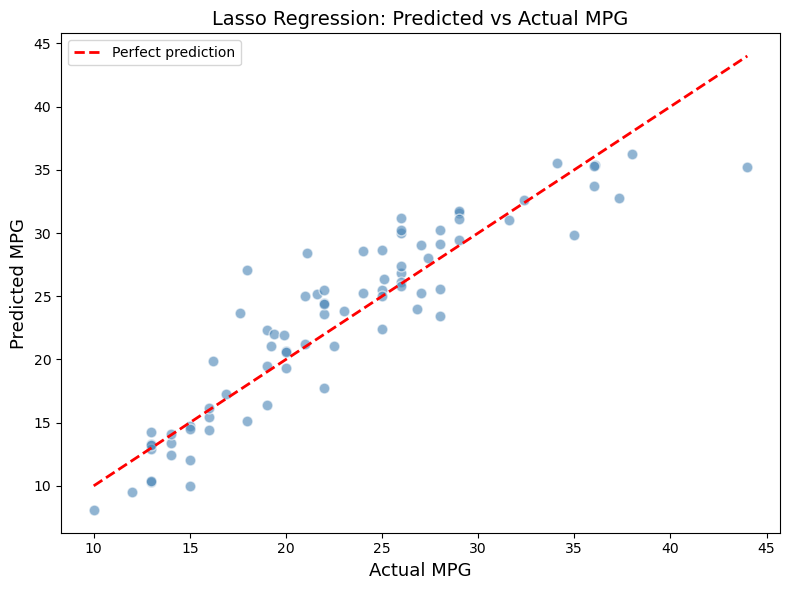

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=60)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual MPG', fontsize=13)
plt.ylabel('Predicted MPG', fontsize=13)
plt.title('Lasso Regression: Predicted vs Actual MPG', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

10. Prediction for a new car

In [20]:
new_car = pd.DataFrame({
    'cylinders':     [4],
    'origin':        [1],          # 1=American, 2=European, 3=Japanese
    'log_weight':    [np.log(2500)],
    'log_horsepower':[np.log(90)],
    'log_displacement':[np.log(140)],
    'acceleration':  [15.0],
    'model':    [80]
})

predicted_mpg = lasso_cv_pipeline.predict(new_car)
print(f"Predicted MPG: {predicted_mpg[0]:.2f}")

Predicted MPG: 28.79


## PCA + Regression Pipeline

Correlation between cylinders, displacement, horsepower and weight!

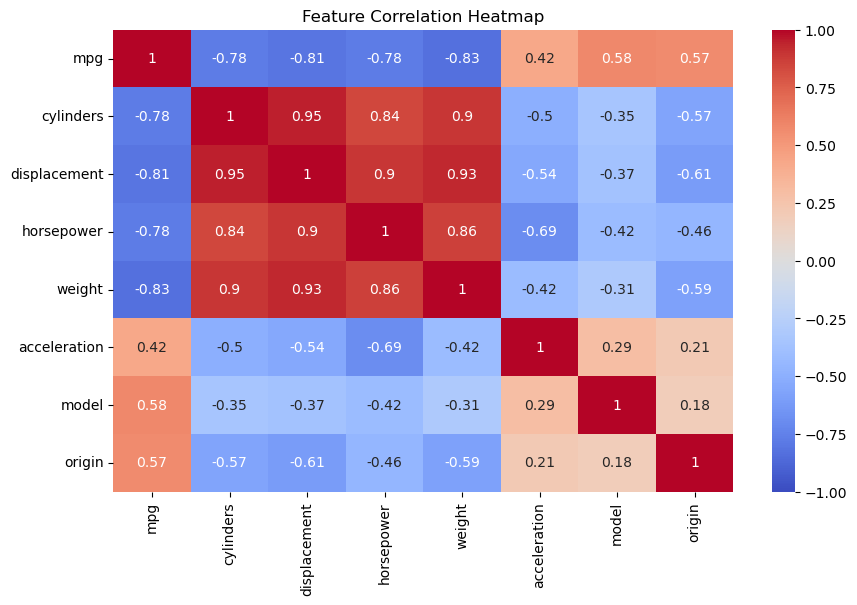

In [21]:
# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

In [22]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# --- Step 1: Log transform skewed features ---
X = cars[['cylinders', 'weight', 'horsepower', 'displacement', 'acceleration', 'model', 'origin']].copy()
y = cars['mpg']

X['weight']       = np.log(X['weight'])
X['horsepower']   = np.log(X['horsepower'])
X['displacement'] = np.log(X['displacement'])

# --- Step 2: Feature groups ---
numerical_features   = ['weight', 'horsepower', 'displacement', 'acceleration', 'model']
categorical_features = ['origin', 'cylinders']

# --- Step 3: Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 4: Preprocessor ---
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# --- Step 5: PCA Pipeline ---
pca_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),  # keep 95% of variance
    ('model', LinearRegression())
])

pca_pipeline.fit(X_train, y_train)

pca_train_r2 = r2_score(y_train, pca_pipeline.predict(X_train))
pca_test_r2  = r2_score(y_test,  pca_pipeline.predict(X_test))
n_components = pca_pipeline.named_steps['pca'].n_components_

print(f"Components selected: {n_components}")
print(f"PCA Train R²:            {pca_train_r2:.4f}")
print(f"PCA Test  R²:            {pca_test_r2:.4f}")
print(f"PCA Gap:                 {pca_train_r2 - pca_test_r2:.4f}")

Components selected: 5
PCA Train R²:            0.8487
PCA Test  R²:            0.8141
PCA Gap:                 0.0346


**PCA vs Lasso CV:**

In [23]:
print("=" * 50)
print(f"{'Model':<22} {'Train R²':>7}  {'Test R²':>7} {'Gap':>6}")
print("=" * 50)
print(f"{'Lasso CV':<22} {lasso_train_r2:>7.4f}  {lasso_test_r2:>7.4f}  {lasso_train_r2 - lasso_test_r2:>6.4f}")
print(f"{'PCA + Regression':<22} {pca_train_r2:>7.4f}  {pca_test_r2:>7.4f}  {pca_train_r2 - pca_test_r2:>6.4f}")
print("=" * 50)

Model                  Train R²  Test R²    Gap
Lasso CV                0.8611   0.8309  0.0302
PCA + Regression        0.8487   0.8141  0.0346


**PCA vs Lasso Comparison: Lasso CV outperforms PCA on every metric and this model still interprets which features matter most.**

**Lasso has higher Test R²**

Lasso explains 83.09% of variance on unseen data
PCA only explains 81.41% — 1.68% worse
Higher test R² = better real-world predictions

**Lasso generalizes better**

Lasso gap = 0.0302 — smaller
PCA gap = 0.0346 — slightly more overfit

**Both are decent models**

Neither is dramatically overfitting
Both gaps are reasonably small

In [24]:
pca = pca_pipeline.named_steps['pca']

explained  = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f"Total components selected: {pca.n_components_}")
print("-" * 55)
print(f"{'Component':<12} {'Variance %':>12}  {'Cumulative %':>12}")
print("-" * 55)
for i, (exp, cum) in enumerate(zip(explained, cumulative)):
    print(f"{i+1:<12} {exp*100:>11.2f}%  {cum*100:>11.2f}%")

Total components selected: 5
-------------------------------------------------------
Component      Variance %  Cumulative %
-------------------------------------------------------
1                  62.52%        62.52%
2                  14.57%        77.10%
3                  12.23%        89.32%
4                   3.83%        93.15%
5                   2.86%        96.01%


**Why?**

PCA reduced 7 features into 5 components — but in doing so:

Lost some information that was useful for prediction

Components are linear combinations of all features, so some signal got mixed/lost

With only 7 features, there wasn't much redundancy to remove in the first place

## Random Forest

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# --- Step 1: Log transform ---
X = cars[['cylinders', 'weight', 'horsepower', 'displacement', 'acceleration', 'model', 'origin']].copy()
y = cars['mpg']

X['weight']       = np.log(X['weight'])
X['horsepower']   = np.log(X['horsepower'])
X['displacement'] = np.log(X['displacement'])

# --- Step 2: Feature groups ---
numerical_features   = ['weight', 'horsepower', 'displacement', 'acceleration', 'model']
categorical_features = ['origin', 'cylinders']

# --- Step 3: Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 4: Preprocessor ---
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# --- Step 5: Random Forest Pipeline ---
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

rf_train_r2 = r2_score(y_train, rf_pipeline.predict(X_train))
rf_test_r2  = r2_score(y_test,  rf_pipeline.predict(X_test))

print(f"RF Train R²: {rf_train_r2:.4f}")
print(f"RF Test  R²: {rf_test_r2:.4f}")
print(f"RF Gap:      {rf_train_r2 - rf_test_r2:.4f}")

RF Train R²: 0.9822
RF Test  R²: 0.8945
RF Gap:      0.0878


**Lasso CV vs PCA + Regression vs Random Forest**

In [26]:
print("=" * 50)
print(f"{'Model':<22} {'Train R²':>7}  {'Test R²':>7} {'Gap':>6}")
print("=" * 50)
print(f"{'Lasso CV':<22} {lasso_train_r2:>7.4f}  {lasso_test_r2:>7.4f}  {lasso_train_r2 - lasso_test_r2:>6.4f}")
print(f"{'PCA + Regression':<22} {pca_train_r2:>7.4f}  {pca_test_r2:>7.4f}  {pca_train_r2 - pca_test_r2:>6.4f}")
print(f"{'Random Forest':<22} {rf_train_r2:>7.4f}  {rf_test_r2:>7.4f}  {rf_train_r2 - rf_test_r2:>6.4f}")
print("=" * 50)

Model                  Train R²  Test R²    Gap
Lasso CV                0.8611   0.8309  0.0302
PCA + Regression        0.8487   0.8141  0.0346
Random Forest           0.9822   0.8945  0.0878


**Conclusion:**

**Random Forest has the best Test R²**

Explains 89.45% of variance on unseen data

Beats Lasso by 6% — that's a meaningful improvement

Likely capturing non-linear relationships Lasso can't

**But Random Forest is overfitting more**

Train R² = 0.98 is suspiciously high — almost perfect on training data

Gap of 0.0878 is nearly 3x larger than Lasso's gap

Means it memorized some training patterns that don't generalize

**Lasso is the most stable**

Smallest gap (0.0302) — most consistent between train and test

Very reliable and interpretable

Random Forest Tuning Round 1:

Test R² = 0.8912 — strong performance

Gap = 0.0601 — acceptable

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators':      [100, 200],
    'model__max_depth':         [5, 10, 15],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf':  [3, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf    = grid_search.best_estimator_
rf_train_r2 = r2_score(y_train, best_rf.predict(X_train))
rf_test_r2  = r2_score(y_test,  best_rf.predict(X_test))

print(f"Best params: {grid_search.best_params_}")
print(f"RF Train R²:    {rf_train_r2:.4f}")
print(f"RF Test  R²:    {rf_test_r2:.4f}")
print(f"RF Gap:         {rf_train_r2 - rf_test_r2:.4f}")

Best params: {'model__max_depth': 15, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100}
RF Train R²:    0.9513
RF Test  R²:    0.8912
RF Gap:         0.0601


Random Forest Tuning Round 2:

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [15, 20, 25],     # explore deeper
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 3]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf    = grid_search.best_estimator_
rf_train_r2   = r2_score(y_train, best_rf.predict(X_train))
rf_test_r2    = r2_score(y_test,  best_rf.predict(X_test))

print(f"Best params: {grid_search.best_params_}")
print(f"RF Train R²:    {rf_train_r2:.4f}")
print(f"RF Test  R²:    {rf_test_r2:.4f}")
print(f"RF Gap:         {rf_train_r2 - rf_test_r2:.4f}")

Best params: {'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
RF Train R²:    0.9739
RF Test  R²:    0.8975
RF Gap:         0.0764
